### Problem Statement:Analyze city lifestyle factors such as average income, rent, population density, internet penetration, air quality, public transport, and green spaces.Identify the factors that have the strongest relationship with the happiness_score. Determine whether income and living costs influence residents happiness.

### Load important libraries and dataset

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report
from scipy.cluster import hierarchy
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv(r"C:\Users\dssas\OneDrive\Desktop\DS\Assignments\Hirarchical clustering\city_lifestyle_dataset.csv")
df.head()

,city_name,country,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
0,Old Vista,Europe,2775,3850,86.4,1310,43,52.0,8.5,23.8
1,Beachport,Europe,3861,3700,78.1,1330,42,62.8,8.1,33.1
2,Valleyborough,Europe,2562,4310,80.1,1330,39,73.2,8.5,40.2
3,City,Europe,3192,3970,81.2,1480,60,49.2,8.5,43.6
4,Falls,Europe,3496,4320,100.0,1510,64,93.7,8.5,42.5


### Understand the structure of dataset. 

In [3]:
df.shape

(300, 10)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city_name               300 non-null    object 
 1   country                 300 non-null    object 
 2   population_density      300 non-null    int64  
 3   avg_income              300 non-null    int64  
 4   internet_penetration    300 non-null    float64
 5   avg_rent                300 non-null    int64  
 6   air_quality_index       300 non-null    int64  
 7   public_transport_score  300 non-null    float64
 8   happiness_score         300 non-null    float64
 9   green_space_ratio       300 non-null    float64
dtypes: float64(4), int64(4), object(2)
memory usage: 23.6+ KB


In [5]:
df.dtypes

city_name                  object
country                    object
population_density          int64
avg_income                  int64
internet_penetration      float64
avg_rent                    int64
air_quality_index           int64
public_transport_score    float64
happiness_score           float64
green_space_ratio         float64
dtype: object

In [6]:
df.describe()

,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,3944.843333,2827.200000,74.305333,1002.766667,71.246667,55.717333,6.644000,33.993333
std,2982.566777,1201.163939,17.014492,456.282066,25.344961,14.712549,1.685864,9.434067
min,100.000000,480.000000,34.000000,170.000000,22.000000,15.000000,2.500000,2.000000
25%,1830.000000,1907.500000,64.400000,640.000000,54.000000,46.075000,5.300000,28.225000
50%,3083.500000,2810.000000,75.000000,990.000000,67.500000,54.700000,6.900000,34.700000
75%,4823.750000,3752.500000,87.225000,1332.500000,86.000000,64.200000,8.500000,40.400000
max,14427.000000,5720.000000,100.000000,2430.000000,146.000000,95.000000,8.500000,58.000000


### EDA (Data Cleaning)

In [7]:
df.isna().sum()

city_name                 0
country                   0
population_density        0
avg_income                0
internet_penetration      0
avg_rent                  0
air_quality_index         0
public_transport_score    0
happiness_score           0
green_space_ratio         0
dtype: int64

In [8]:
df.replace(['?','',' ','empty','#','-'], np.nan, inplace=True) # replacing all with NaN value

In [9]:
df.isna().sum()

city_name                 0
country                   0
population_density        0
avg_income                0
internet_penetration      0
avg_rent                  0
air_quality_index         0
public_transport_score    0
happiness_score           0
green_space_ratio         0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

### Outlier Detection

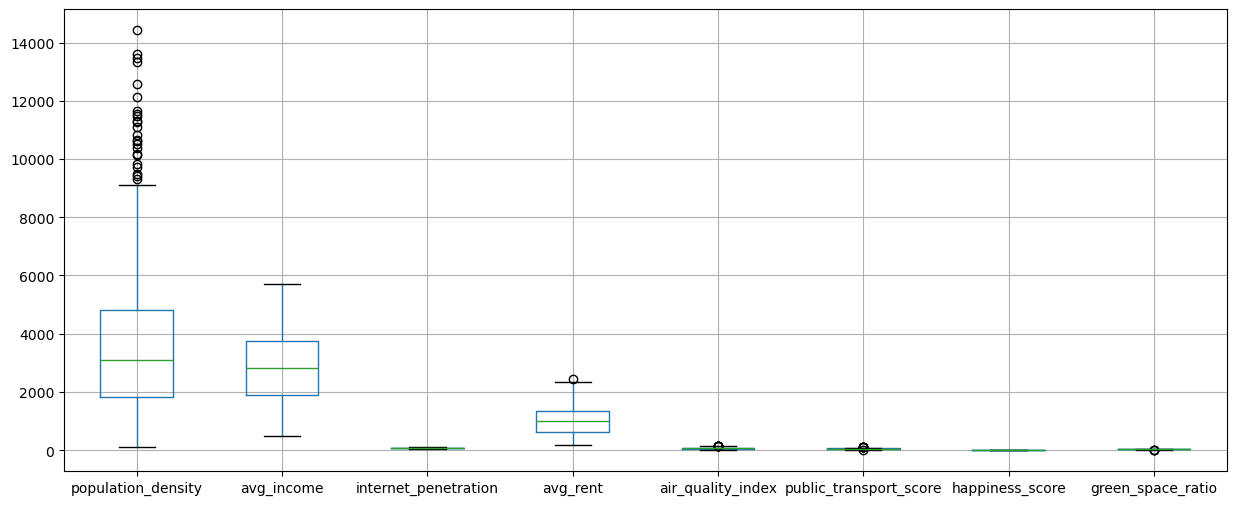

In [11]:
plt.figure(figsize=(15,6))
df.boxplot()
plt.show()

### Making the copy of dataset to compaire the clusters

In [12]:
x=df.copy()
x.head()

,city_name,country,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
0,Old Vista,Europe,2775,3850,86.4,1310,43,52.0,8.5,23.8
1,Beachport,Europe,3861,3700,78.1,1330,42,62.8,8.1,33.1
2,Valleyborough,Europe,2562,4310,80.1,1330,39,73.2,8.5,40.2
3,City,Europe,3192,3970,81.2,1480,60,49.2,8.5,43.6
4,Falls,Europe,3496,4320,100.0,1510,64,93.7,8.5,42.5


### Encoding of catogorical columns

In [13]:
x['city_name'].unique()

array(['Old Vista', 'Beachport', 'Valleyborough', 'City', 'Falls',
       'North Falls', 'Hillhaven', 'Gardenton', 'Springsville',
       'North Ridge', 'Ridgeshire', 'Forestville', 'Garden', 'Bridge',
       'Port Bridge', 'Stone', 'Riverburg', 'Gardenburg', 'Pointborough',
       'Parkland', 'Cityport', 'Cityhaven', 'San Wood', 'Harborshire',
       'East Valley', 'Valleyburg', 'Point', 'Woodshire', 'New Wood',
       'Port Beach', 'Fallshaven', 'Vistaland', 'San Vista', 'Bayport',
       'Field', 'North Harbor', 'Forestshire', 'Springs', 'Mount City',
       'River', 'Port Springs', 'Hill', 'New Park', 'Lake Town', 'Wood',
       'Townland', 'Town', 'Woodland', 'Pointland', 'San Harbor',
       'Saint Falls', 'Fieldton', 'New Hill', 'Port Stone', 'West Stone',
       'Woodport', 'Harborport', 'South Forest', 'Mount Valley',
       'Bridgedale', 'Pointshire', 'Forestdale', 'Woodburg', 'North City',
       'Riverford', 'Gardenborough', 'San Point', 'Saint Forest', 'Bay',
       'Mount

### Due to the large number of unique cities, encoding the city variable would create too many features and may not provide meaningful insights for our analysis. Therefore, we have excluded this variable from the modelling process.

In [14]:
x['country'].unique()

array(['Europe', 'Asia', 'North America', 'South America', 'Africa',
       'Oceania'], dtype=object)

In [15]:
oe=OrdinalEncoder()
x['country']=oe.fit_transform(x[['country']])
x.head()

,city_name,country,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
0,Old Vista,2.0,2775,3850,86.4,1310,43,52.0,8.5,23.8
1,Beachport,2.0,3861,3700,78.1,1330,42,62.8,8.1,33.1
2,Valleyborough,2.0,2562,4310,80.1,1330,39,73.2,8.5,40.2
3,City,2.0,3192,3970,81.2,1480,60,49.2,8.5,43.6
4,Falls,2.0,3496,4320,100.0,1510,64,93.7,8.5,42.5


### Dropping the column "city_name"

In [16]:
x.drop(columns=['city_name'],inplace=True)
x.head()

,country,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
0,2.0,2775,3850,86.4,1310,43,52.0,8.5,23.8
1,2.0,3861,3700,78.1,1330,42,62.8,8.1,33.1
2,2.0,2562,4310,80.1,1330,39,73.2,8.5,40.2
3,2.0,3192,3970,81.2,1480,60,49.2,8.5,43.6
4,2.0,3496,4320,100.0,1510,64,93.7,8.5,42.5


### Scaling is important in clustering because clustering algorithms use distance calculations to determine how similar or different data points are.

In [17]:
sc=StandardScaler()
x=sc.fit_transform(x)
x

array([[-1.90628344e-01, -3.92882389e-01,  8.52930151e-01, ...,
        -2.53086289e-01,  1.10275857e+00, -1.08228661e+00],
       [-1.90628344e-01, -2.81581030e-02,  7.27842624e-01, ...,
         4.82207450e-01,  8.65095083e-01, -9.48504942e-02],
       [-1.90628344e-01, -4.64416710e-01,  1.23653190e+00, ...,
         1.19026809e+00,  1.10275857e+00,  6.58998583e-01],
       ...,
       [ 1.08022728e+00, -1.04407980e+00,  9.02965162e-01, ...,
        -1.18010106e-03,  1.10275857e+00,  4.89117101e-01],
       [ 1.08022728e+00, -1.07027547e+00,  5.52720086e-01, ...,
        -1.10112507e-01,  1.10275857e+00,  1.12617266e+00],
       [ 1.08022728e+00, -9.10078890e-01,  1.25321024e+00, ...,
         1.33324187e+00,  1.10275857e+00,  6.27145805e-01]])

### Dendrogram

### Create linkage matrix for heirarchical clustering

In [19]:
lk=hierarchy.linkage(x, method='complete')

### Visual representation of hierarchical clustering

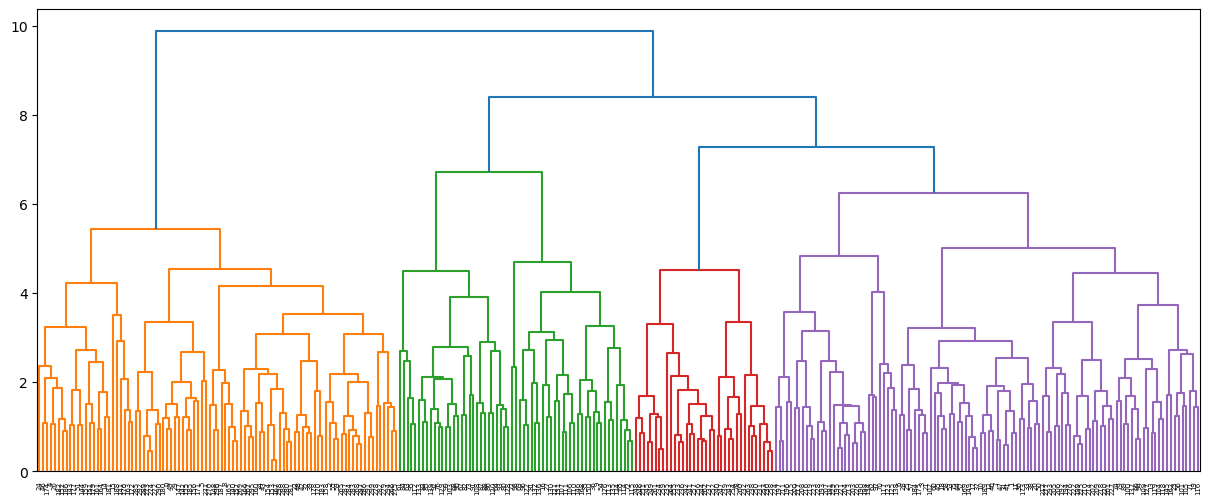

In [20]:
plt.figure(figsize=(15,6))
dendrogram=hierarchy.dendrogram(lk)

### Model Building

### Creates a hierarchical clustering model using Aglomerative method

In [21]:
hc=AgglomerativeClustering(n_clusters=2)

### Learn the cluster structure from data and assign cluster labels to each row.

In [22]:
labels=hc.fit_predict(x)
labels

array([1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1,
       0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

### Analyse the cluster

In [23]:
df['2 cluster']=labels
df.head()

,city_name,country,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio,2 cluster
0,Old Vista,Europe,2775,3850,86.4,1310,43,52.0,8.5,23.8,1
1,Beachport,Europe,3861,3700,78.1,1330,42,62.8,8.1,33.1,0
2,Valleyborough,Europe,2562,4310,80.1,1330,39,73.2,8.5,40.2,1
3,City,Europe,3192,3970,81.2,1480,60,49.2,8.5,43.6,1
4,Falls,Europe,3496,4320,100.0,1510,64,93.7,8.5,42.5,1


In [26]:
df.drop(columns=['city_name','country']).groupby('2 cluster').mean()

,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
2 cluster,,,,,,,,
0,4923.135,2182.2,66.855,773.75,82.395,52.1855,5.7515,32.59
1,1988.260,4117.2,89.206,1460.80,48.950,62.7810,8.4290,36.80


### Visual representation using scatterplot

<Axes: xlabel='population_density', ylabel='public_transport_score'>

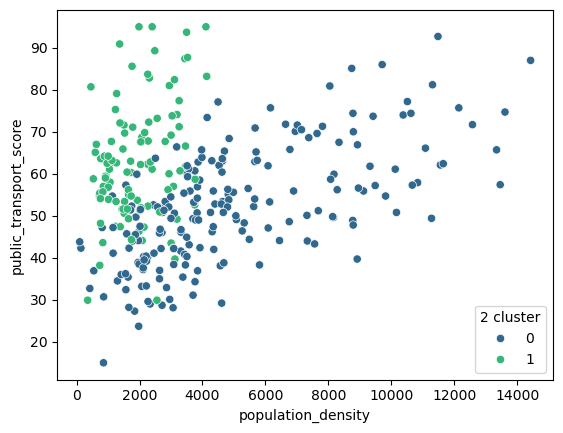

In [27]:
sns.scatterplot(x=df['population_density'], y=df['public_transport_score'], hue=df['2 cluster'], palette='viridis')

### supervised classification model

In [28]:
x

array([[-1.90628344e-01, -3.92882389e-01,  8.52930151e-01, ...,
        -2.53086289e-01,  1.10275857e+00, -1.08228661e+00],
       [-1.90628344e-01, -2.81581030e-02,  7.27842624e-01, ...,
         4.82207450e-01,  8.65095083e-01, -9.48504942e-02],
       [-1.90628344e-01, -4.64416710e-01,  1.23653190e+00, ...,
         1.19026809e+00,  1.10275857e+00,  6.58998583e-01],
       ...,
       [ 1.08022728e+00, -1.04407980e+00,  9.02965162e-01, ...,
        -1.18010106e-03,  1.10275857e+00,  4.89117101e-01],
       [ 1.08022728e+00, -1.07027547e+00,  5.52720086e-01, ...,
        -1.10112507e-01,  1.10275857e+00,  1.12617266e+00],
       [ 1.08022728e+00, -9.10078890e-01,  1.25321024e+00, ...,
         1.33324187e+00,  1.10275857e+00,  6.27145805e-01]])

In [29]:
y=df['2 cluster']

### Split data for training and testing

In [33]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)

In [34]:
lr=LogisticRegression()
lr.fit(xtrain,ytrain)

LogisticRegression()

In [35]:
ypred=lr.predict(xtest)
ypred

array([0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0])

In [36]:
ytest

203    0
266    1
152    1
9      0
233    0
226    0
196    0
109    0
5      1
175    1
237    0
57     0
218    0
45     0
182    1
221    0
289    1
211    0
148    1
165    1
78     0
113    0
249    0
250    0
104    0
42     1
281    1
295    1
157    1
238    0
17     0
164    1
33     0
24     1
215    0
119    0
7      0
90     0
46     1
73     0
93     0
76     0
286    1
60     0
77     0
63     0
234    0
229    0
111    0
231    0
180    1
144    1
239    0
75     0
297    1
278    1
97     0
92     0
192    0
25     0
Name: 2 cluster, dtype: int64

### Evaluation Of clustering model

#### The Silhouette Score is a metric used to evaluate the quality of clusters. It tells us how well each data point fits within its own cluster compared with other clusters.

In [38]:
from sklearn.metrics import silhouette_score 

In [40]:
silhouette_score(x, labels)

np.float64(0.2685670923893016)

### A Silhouette Score of 0.268 indicates that your clusters have some separation, but the clustering is not very strong.

### Try different numbers of clusters and compare their silhouette scores

In [42]:
hc=AgglomerativeClustering(n_clusters=4)

In [43]:
labels=hc.fit_predict(x)
labels

array([1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1,
       0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 3, 3, 3, 3, 0,
       0, 3, 3, 3, 0, 0, 0, 3, 0, 0, 3, 3, 2, 0, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 0, 3, 3, 3, 3, 0, 3, 3, 3, 3, 3, 0, 0, 0, 3, 0, 0, 3, 3, 3, 0,
       3, 3, 3, 3, 0, 0, 0, 0, 0, 0, 3, 3, 3, 0, 3, 0, 3, 0, 3, 3, 0, 3,
       3, 3, 3, 3, 3, 0, 0, 3, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [44]:
df['4 Clusters']= labels

In [45]:
df.drop(columns= ['city_name','country']).groupby('4 Clusters').mean()

,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio,2 cluster
4 Clusters,,,,,,,,,
0,3815.324561,2406.052632,70.607895,868.070175,72.921053,51.473684,6.372807,34.168421,0.0
1,1988.260000,4117.200000,89.206000,1460.800000,48.950000,62.781000,8.429000,36.800000,1.0
2,2133.222222,882.222222,44.750000,301.944444,83.666667,35.802778,4.083333,39.147222,0.0
3,9457.680000,2607.800000,74.214000,898.400000,103.080000,65.604000,5.536000,24.270000,0.0


<Axes: xlabel='population_density', ylabel='public_transport_score'>

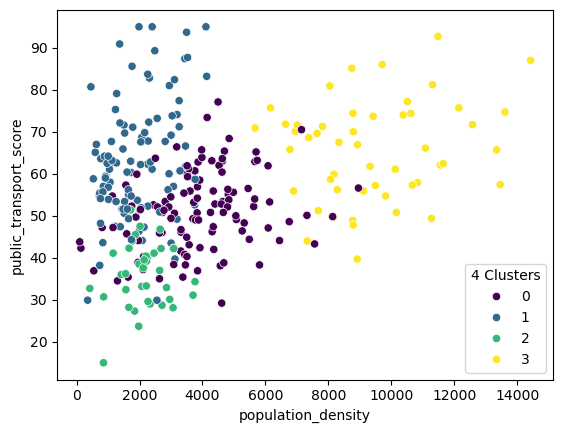

In [47]:
sns.scatterplot(x=df['population_density'], y=df['public_transport_score'],hue=df['4 Clusters'], palette='viridis')

In [48]:
x

array([[-1.90628344e-01, -3.92882389e-01,  8.52930151e-01, ...,
        -2.53086289e-01,  1.10275857e+00, -1.08228661e+00],
       [-1.90628344e-01, -2.81581030e-02,  7.27842624e-01, ...,
         4.82207450e-01,  8.65095083e-01, -9.48504942e-02],
       [-1.90628344e-01, -4.64416710e-01,  1.23653190e+00, ...,
         1.19026809e+00,  1.10275857e+00,  6.58998583e-01],
       ...,
       [ 1.08022728e+00, -1.04407980e+00,  9.02965162e-01, ...,
        -1.18010106e-03,  1.10275857e+00,  4.89117101e-01],
       [ 1.08022728e+00, -1.07027547e+00,  5.52720086e-01, ...,
        -1.10112507e-01,  1.10275857e+00,  1.12617266e+00],
       [ 1.08022728e+00, -9.10078890e-01,  1.25321024e+00, ...,
         1.33324187e+00,  1.10275857e+00,  6.27145805e-01]])

In [49]:
y=df['4 Clusters']

In [50]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2, random_state=42)

In [51]:
lr=LogisticRegression()
lr.fit(xtrain,ytrain)

LogisticRegression()

In [52]:
ypred=lr.predict(xtest)
ypred

array([0, 1, 1, 0, 2, 0, 0, 0, 1, 1, 2, 0, 0, 0, 1, 0, 1, 0, 1, 1, 2, 3,
       2, 2, 0, 1, 1, 1, 1, 2, 0, 1, 0, 1, 0, 0, 1, 3, 1, 3, 3, 3, 1, 0,
       3, 3, 2, 0, 3, 2, 1, 1, 2, 0, 1, 1, 3, 3, 0, 0])

In [53]:
ytest

203    0
266    1
152    1
9      0
233    2
226    0
196    0
109    0
5      1
175    1
237    2
57     0
218    0
45     0
182    1
221    0
289    1
211    0
148    1
165    1
78     2
113    3
249    2
250    2
104    0
42     1
281    1
295    1
157    1
238    2
17     0
164    1
33     0
24     1
215    0
119    0
7      0
90     3
46     1
73     3
93     3
76     3
286    1
60     0
77     3
63     3
234    2
229    0
111    3
231    2
180    1
144    1
239    2
75     0
297    1
278    1
97     3
92     3
192    0
25     0
Name: 4 Clusters, dtype: int64

In [54]:
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.98        21
           1       0.95      1.00      0.98        20
           2       1.00      1.00      1.00         9
           3       1.00      1.00      1.00        10

    accuracy                           0.98        60
   macro avg       0.99      0.99      0.99        60
weighted avg       0.98      0.98      0.98        60



In [55]:
silhouette_score(x,labels)

np.float64(0.27101179117580737)

### This is slightly better than your previous score of 0.269.

### conclusion: A score of 0.270 indicates:

#### There is some separation between the clusters.
#### However, the clusters overlap to some extent.
#### The clustering quality is weak to moderate.

### for better Silhouette score 

In [58]:
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(x)
    
    score = silhouette_score(x, labels)
    print("K =", k, "Silhouette Score =", score)

K = 2 Silhouette Score = 0.3251943382726612
K = 3 Silhouette Score = 0.3350321886678655
K = 4 Silhouette Score = 0.35438315199312154
K = 5 Silhouette Score = 0.28918377101004505
K = 6 Silhouette Score = 0.2532193701359406
K = 7 Silhouette Score = 0.24620579080814806
K = 8 Silhouette Score = 0.23490668102560416
K = 9 Silhouette Score = 0.19990027783041928
